# Netflix Data Analysis & Predictive Classification

## Project Overview

This project focuses on analyzing Netflix content data to uncover patterns in content distribution and build a machine learning model to classify titles as Movies or TV Shows.

The study combines exploratory data analysis and predictive modeling to understand how features such as release year, genre diversity, and rating influence content classification.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("netflix_titles.csv")
df.head()

Saving netflix_titles.csv to netflix_titles (1).csv


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Understanding

In [23]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Observation
The dataset contains information about Netflix titles including type, genre, release year, rating, and more.

## Data Cleaning

In [5]:
# Check missing values
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [24]:
# Fill missing values
df.fillna({
    'director': 'Unknown',
    'cast': 'Unknown',
    'country': 'Unknown',
    'rating': 'Not Rated'
}, inplace=True)
df = df.dropna(subset=['type'])

### Insight
Missing values in important columns were handled to ensure data consistency.

## Exploratory Data Analysis

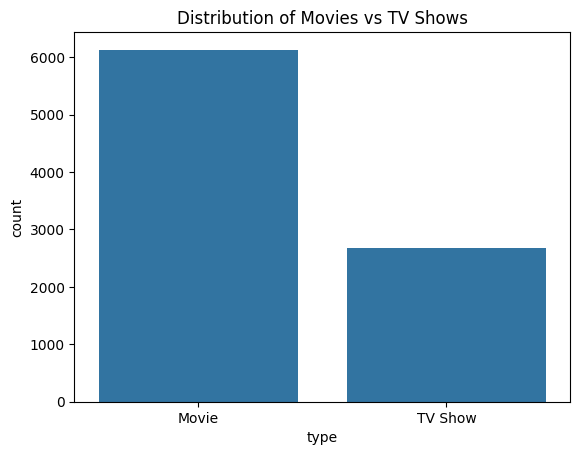

In [25]:
sns.countplot(x='type', data=df)
plt.title("Distribution of Movies vs TV Shows")
plt.show()

Movies significantly outnumber TV shows, indicating Netflix’s stronger focus on film-based content.

In [8]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


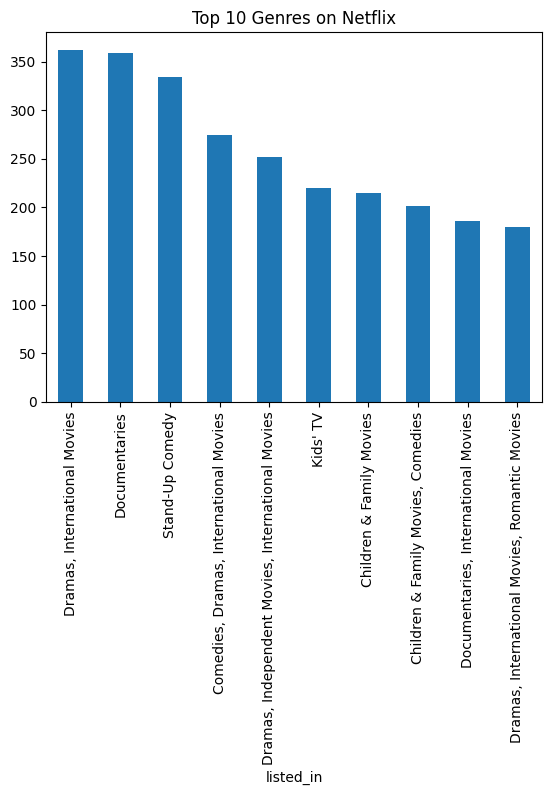

In [26]:
df['listed_in'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.show()

Drama and international genres dominate, suggesting a diverse global audience preference.

In [9]:
df['release_year'].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


In [10]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


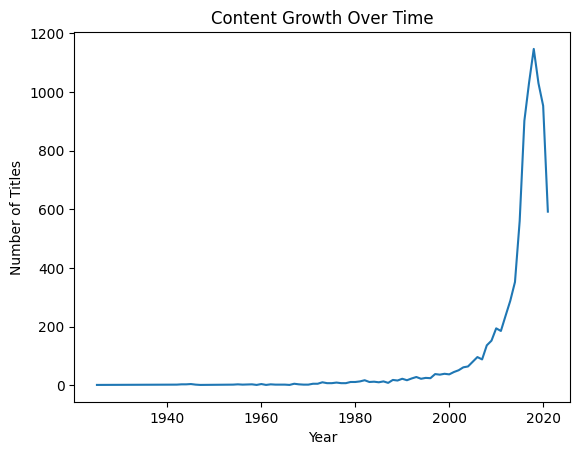

In [28]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

This trend aligns with Netflix’s global expansion phase and increased investment in original content production.

## Feature Engineering

In [11]:
df = df.dropna(subset=['type'])  # remove missing target

In [27]:
df['genre_count'] = df['listed_in'].apply(lambda x: len(str(x).split(',')))
df['title_length'] = df['title'].apply(len)
df['is_recent'] = (df['release_year'] > 2015).astype(int)

### Explanation
- `genre_count`: Number of genres per title  
- `title_length`: Length of title text  
- `is_recent`: Indicates modern content (post-2015)  

## Model Building

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])
df['rating'] = le.fit_transform(df['rating'])

In [33]:
X = df[['release_year', 'rating', 'genre_count', 'title_length', 'is_recent']]
y = df['type']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Model Evaluation

In [35]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.6940976163450624
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      1243
           1       0.48      0.41      0.44       519

    accuracy                           0.69      1762
   macro avg       0.62      0.61      0.62      1762
weighted avg       0.68      0.69      0.69      1762



In [36]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7150964812712827


In [37]:
dt_acc = accuracy_score(y_test, dt_pred)
lr_acc = accuracy_score(y_test, lr_pred)

print("Decision Tree:", dt_acc)
print("Logistic Regression:", lr_acc)

Decision Tree: 0.6940976163450624
Logistic Regression: 0.7150964812712827


Logistic Regression performs slightly better than Decision Tree, suggesting that the relationship between features and target is relatively linear.

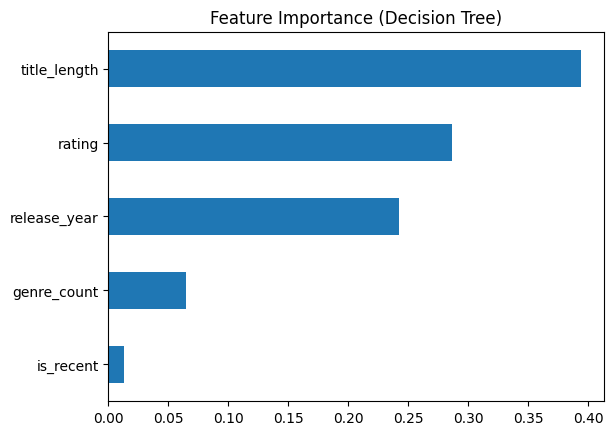

In [40]:
import pandas as pd

importance = pd.Series(dt_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance (Decision Tree)")
plt.show()

Feature importance analysis shows that release year and genre count contribute significantly to classification, indicating their strong influence on content type.

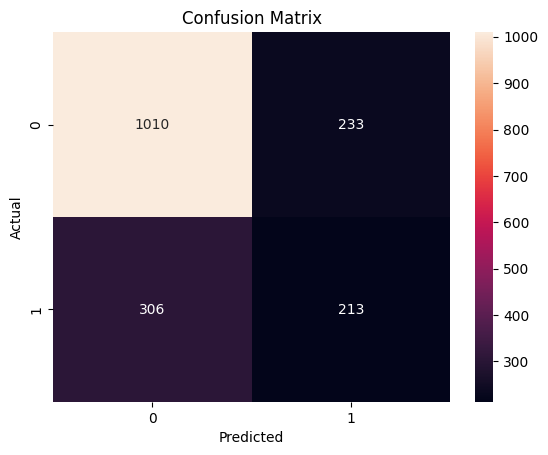

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model predicts Movies more accurately than TV Shows, indicating a slight class imbalance and suggesting room for improvement in detecting TV Shows.

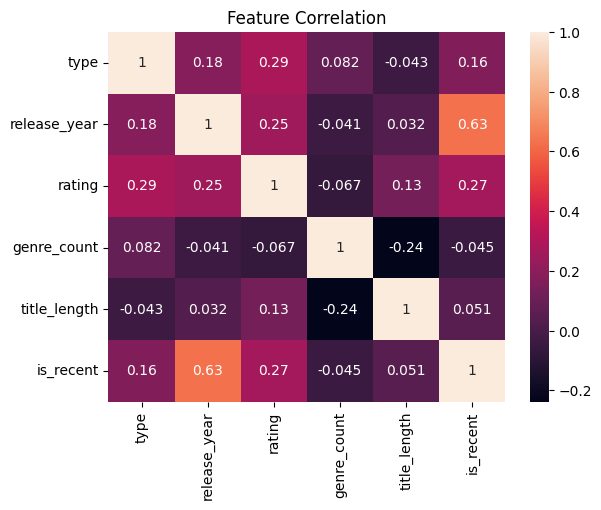

In [39]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

## Real-World Relevance

This project demonstrates how data analysis and machine learning can help streaming platforms understand content distribution patterns.

Such insights can be used to:
- Improve content recommendation systems
- Optimize content acquisition strategies
- Enhance user engagement by aligning with audience preferences

## Limitations

The model is trained on limited features and does not include user engagement data such as views or ratings, which could improve prediction accuracy.

## Final Conclusion

This project analyzed Netflix content data to uncover trends and classify content types using machine learning.

Logistic Regression slightly outperformed Decision Tree, making it a stronger baseline model for this classification task.

This project demonstrates the ability to apply end-to-end data science techniques, from data preprocessing and visualization to predictive modeling and evaluation, on a real-world dataset.